# Orchlon's part

## **KNN and K mean**

In [163]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
amazon_df = pd.read_csv('amazon.csv')

print("Dataset shape:", amazon_df.shape)
print("\nFirst few rows:")
amazon_df.head()

Dataset shape: (1465, 16)

First few rows:


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


### Data Exploration and Preprocessing


In [164]:
# Check data info
print("Dataset Information:")
print(amazon_df.info())
print("\nMissing Values:")
print(amazon_df.isnull().sum())
print("\nBasic Statistics:")
print(amazon_df.describe())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null

In [165]:
# Data Preprocessing
# Clean price columns - remove ₹ and commas
amazon_df['discounted_price_clean'] = amazon_df['discounted_price'].str.replace('₹', '').str.replace(',', '').astype(float)
amazon_df['actual_price_clean'] = amazon_df['actual_price'].str.replace('₹', '').str.replace(',', '').astype(float)

# Clean discount percentage - remove %
amazon_df['discount_percentage_clean'] = amazon_df['discount_percentage'].str.replace('%', '').astype(float)

# Convert rating to numeric and handle missing values
amazon_df['rating'] = pd.to_numeric(amazon_df['rating'], errors='coerce')
amazon_df['rating'].fillna(amazon_df['rating'].median(), inplace=True)

# Clean rating_count - remove commas and convert to numeric
amazon_df['rating_count_clean'] = amazon_df['rating_count'].astype(str).str.replace(',', '')
amazon_df['rating_count_clean'] = pd.to_numeric(amazon_df['rating_count_clean'], errors='coerce')

# Create a copy for modeling
df_model = amazon_df[['discounted_price_clean', 'actual_price_clean', 
                       'discount_percentage_clean', 'rating', 'rating_count_clean']].copy()

# Rename for convenience
df_model.rename(columns={'rating_count_clean': 'rating_count'}, inplace=True)

# Remove any remaining missing values
df_model = df_model.dropna()

print("Preprocessed data shape:", df_model.shape)
print("\nPreprocessed data sample:")
df_model.head()


Preprocessed data shape: (1463, 5)

Preprocessed data sample:


,discounted_price_clean,actual_price_clean,discount_percentage_clean,rating,rating_count
0,399.0,1099.0,64.0,4.2,24269.0
1,199.0,349.0,43.0,4.0,43994.0
2,199.0,1899.0,90.0,3.9,7928.0
3,329.0,699.0,53.0,4.2,94363.0
4,154.0,399.0,61.0,4.2,16905.0


### **K-Nearest Neighbors (KNN) Classification**

We'll classify products into rating categories (Low, Medium, High) based on their features.


In [166]:
# Create rating categories for classification
def categorize_rating(rating):
    if rating < 3.5:
        return 'Low'
    elif rating < 4.0:
        return 'Medium'
    else:
        return 'High'

df_model['rating_category'] = df_model['rating'].apply(categorize_rating)

# Prepare features and target for KNN
X = df_model[['discounted_price_clean', 'actual_price_clean', 
              'discount_percentage_clean', 'rating_count']]
y = df_model['rating_category']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nRating category distribution:")
print(y.value_counts())


Training set size: 1024
Test set size: 439

Rating category distribution:
rating_category
High      1110
Medium     312
Low         41
Name: count, dtype: int64


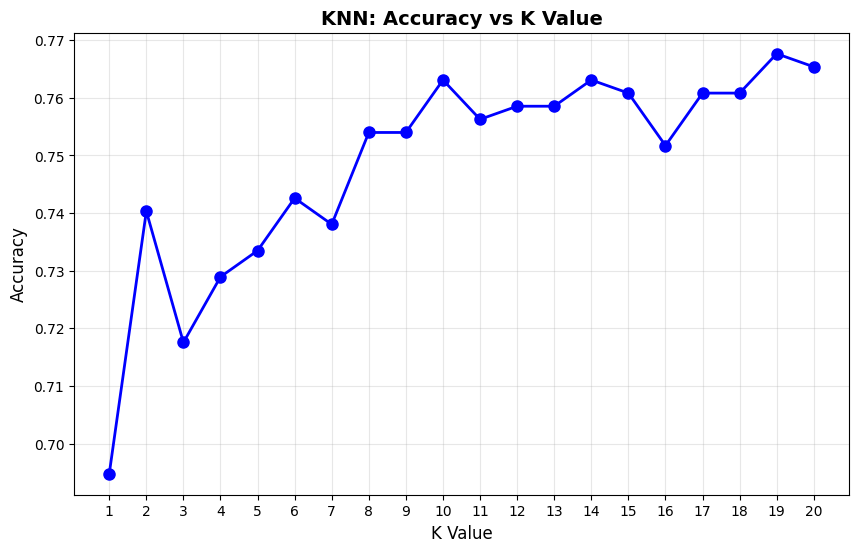

Best K value: 19
Best accuracy: 0.7677


In [167]:
# Find optimal K value
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred))

# Plot accuracy vs K
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, 'bo-', linewidth=2, markersize=8)
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('KNN: Accuracy vs K Value', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.show()

# Find best K
best_k = k_values[accuracies.index(max(accuracies))]
print(f"Best K value: {best_k}")
print(f"Best accuracy: {max(accuracies):.4f}")


KNN CLASSIFICATION RESULTS

Accuracy: 0.7677

Classification Report:

              precision    recall  f1-score   support

        High       0.78      0.97      0.87       337
         Low       0.00      0.00      0.00        14
      Medium       0.48      0.11      0.18        88

    accuracy                           0.77       439
   macro avg       0.42      0.36      0.35       439
weighted avg       0.70      0.77      0.70       439



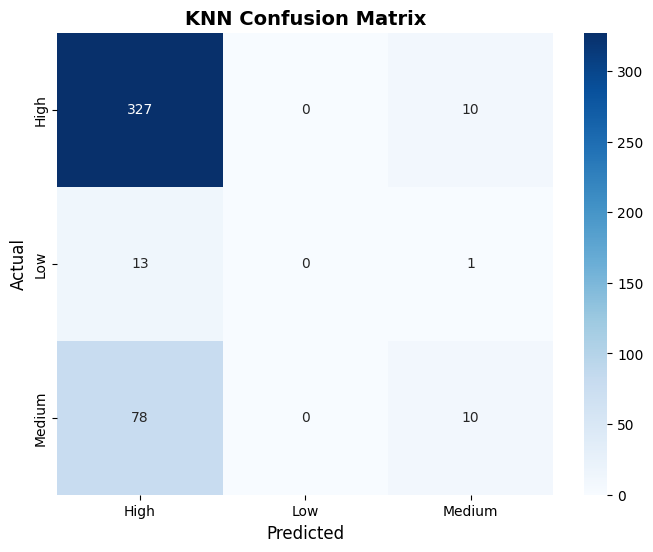

In [168]:
# Train final KNN model with best K
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)

# Make predictions
y_pred_knn = knn_final.predict(X_test_scaled)

# Evaluate the model
print("KNN CLASSIFICATION RESULTS")
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"\nClassification Report:\n")
print(classification_report(y_test, y_pred_knn))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['High', 'Low', 'Medium'],
            yticklabels=['High', 'Low', 'Medium'])
plt.title('KNN Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.show()


### **K-Means Clustering**

We'll cluster products based on their features to identify natural groupings.


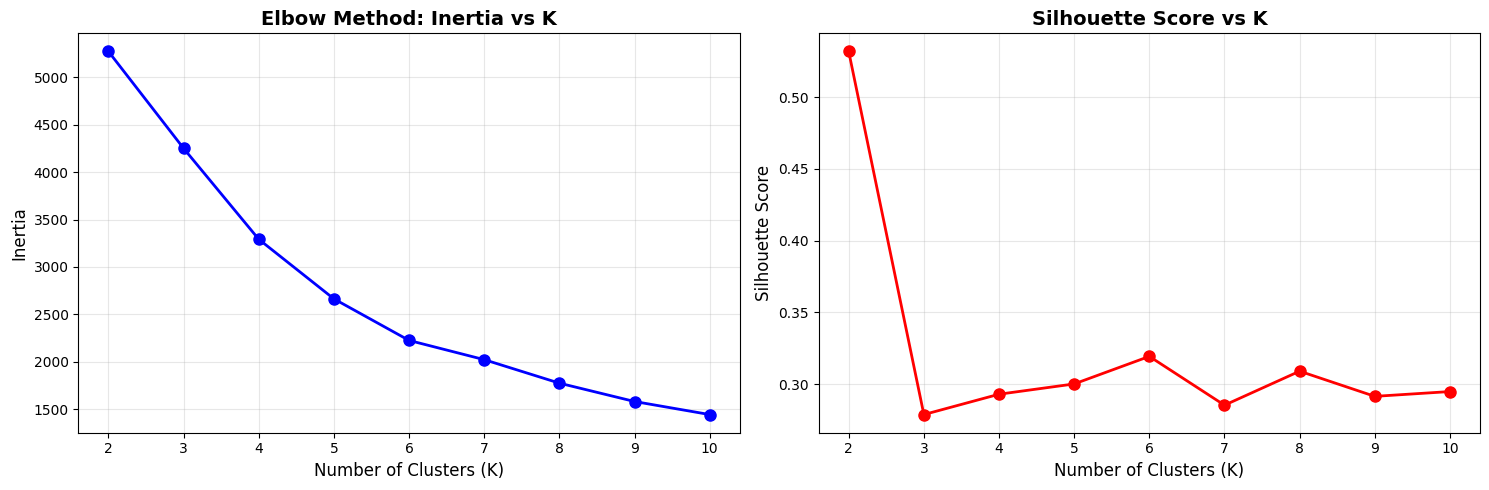

Best K value (based on silhouette score): 2
Best silhouette score: 0.5319


In [169]:
# Prepare data for K-Means
X_kmeans = df_model[['discounted_price_clean', 'actual_price_clean', 
                     'discount_percentage_clean', 'rating', 'rating_count']]

# Scale the features
scaler_kmeans = StandardScaler()
X_kmeans_scaled = scaler_kmeans.fit_transform(X_kmeans)

# Elbow Method to find optimal number of clusters
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_kmeans_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_kmeans_scaled, kmeans.labels_))

# Plot Elbow Curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Inertia plot
ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia', fontsize=12)
ax1.set_title('Elbow Method: Inertia vs K', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(K_range)

# Silhouette score plot
ax2.plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (K)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score vs K', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(K_range)

plt.tight_layout()
plt.show()

# Find best K based on silhouette score
best_k_kmeans = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f"Best K value (based on silhouette score): {best_k_kmeans}")
print(f"Best silhouette score: {max(silhouette_scores):.4f}")


In [170]:
# Train final K-Means model
kmeans_final = KMeans(n_clusters=best_k_kmeans, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_kmeans_scaled)

# Add cluster labels to the dataframe
df_model['cluster'] = cluster_labels

print("K-MEANS CLUSTERING RESULTS")
print(f"\nNumber of clusters: {best_k_kmeans}")
print(f"Silhouette Score: {silhouette_score(X_kmeans_scaled, cluster_labels):.4f}")
print(f"\nCluster distribution:")
print(df_model['cluster'].value_counts().sort_index())


K-MEANS CLUSTERING RESULTS

Number of clusters: 2
Silhouette Score: 0.5319

Cluster distribution:
cluster
0    1346
1     117
Name: count, dtype: int64


In [171]:
# Analyze cluster characteristics
print("CLUSTER CHARACTERISTICS")

for cluster in range(best_k_kmeans):
    cluster_data = df_model[df_model['cluster'] == cluster]
    print(f"\n{'Cluster ' + str(cluster)}")
    print(f"Size: {len(cluster_data)} products")
    print(f"Average discounted price: ₹{cluster_data['discounted_price_clean'].mean():.2f}")
    print(f"Average actual price: ₹{cluster_data['actual_price_clean'].mean():.2f}")
    print(f"Average discount: {cluster_data['discount_percentage_clean'].mean():.2f}%")
    print(f"Average rating: {cluster_data['rating'].mean():.2f}")
    print(f"Average rating count: {cluster_data['rating_count'].mean():.0f}")


CLUSTER CHARACTERISTICS

Cluster 0
Size: 1346 products
Average discounted price: ₹1418.31
Average actual price: ₹2879.99
Average discount: 48.97%
Average rating: 4.09
Average rating count: 18453

Cluster 1
Size: 117 products
Average discounted price: ₹22812.68
Average actual price: ₹35029.49
Average discount: 32.50%
Average rating: 4.20
Average rating count: 16480


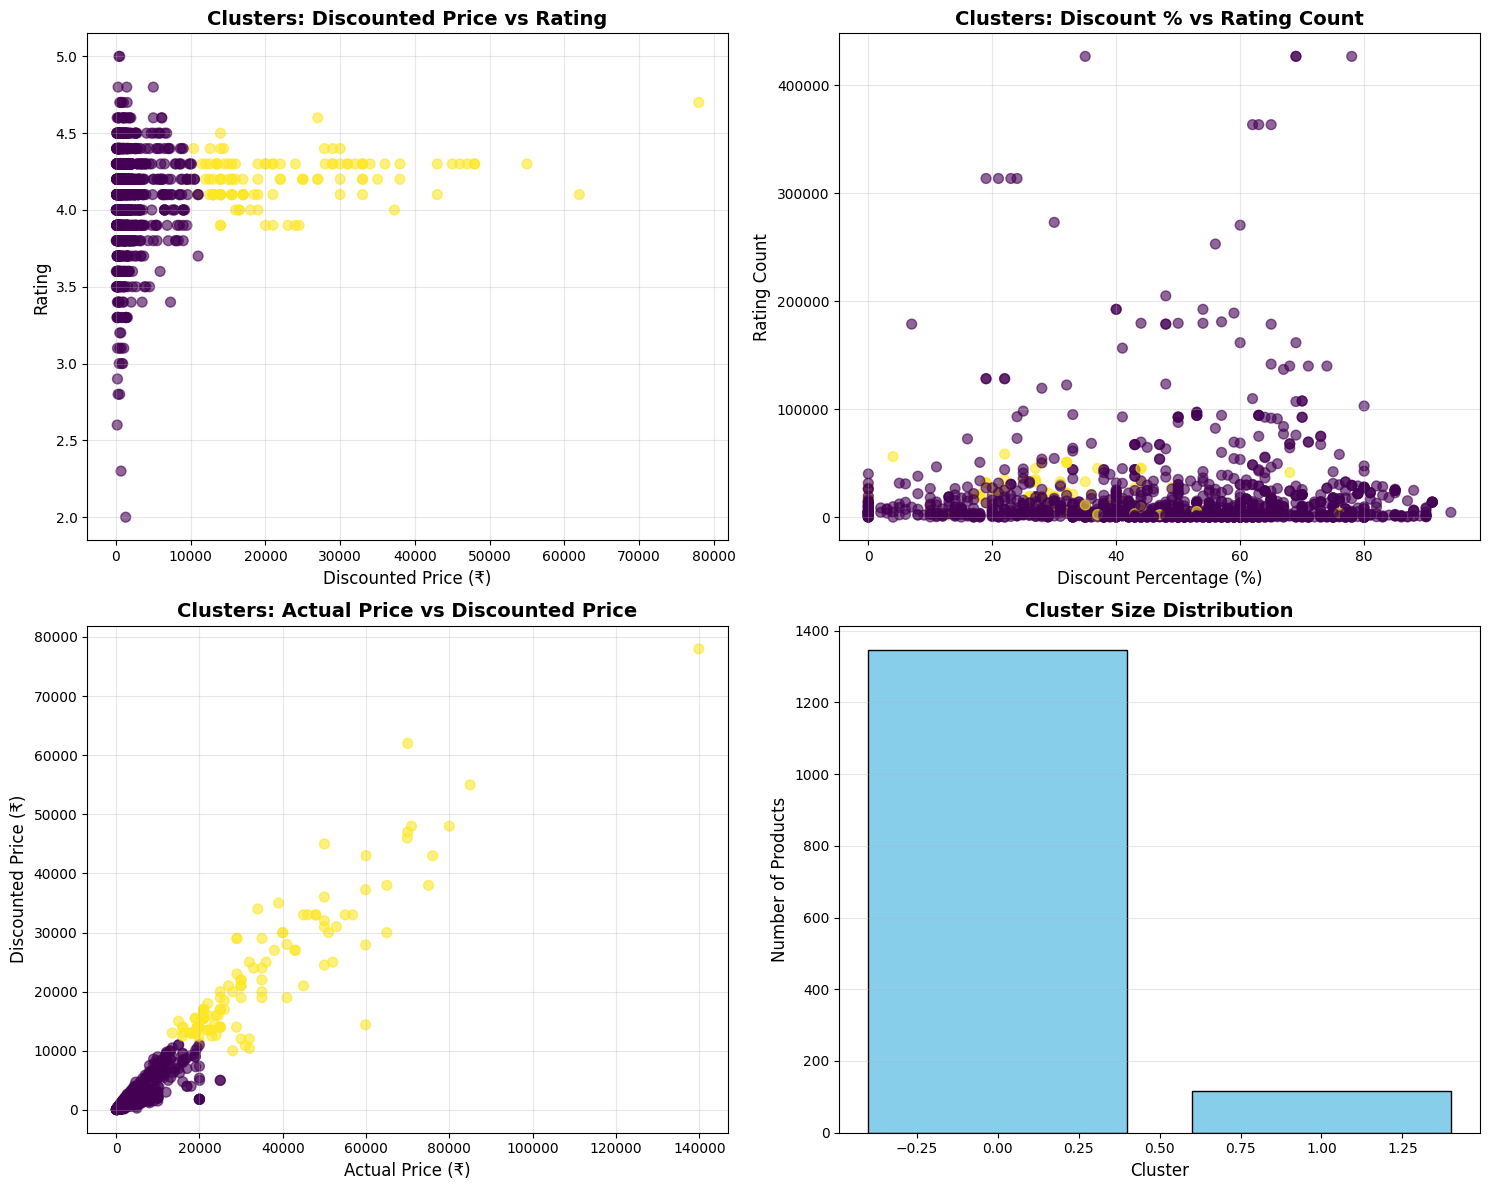

In [172]:
# Visualize clusters
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Discounted Price vs Rating
axes[0, 0].scatter(df_model['discounted_price_clean'], df_model['rating'], 
                   c=df_model['cluster'], cmap='viridis', alpha=0.6, s=50)
axes[0, 0].set_xlabel('Discounted Price (₹)', fontsize=12)
axes[0, 0].set_ylabel('Rating', fontsize=12)
axes[0, 0].set_title('Clusters: Discounted Price vs Rating', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Discount Percentage vs Rating Count
axes[0, 1].scatter(df_model['discount_percentage_clean'], df_model['rating_count'], 
                   c=df_model['cluster'], cmap='viridis', alpha=0.6, s=50)
axes[0, 1].set_xlabel('Discount Percentage (%)', fontsize=12)
axes[0, 1].set_ylabel('Rating Count', fontsize=12)
axes[0, 1].set_title('Clusters: Discount % vs Rating Count', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Actual Price vs Discounted Price
axes[1, 0].scatter(df_model['actual_price_clean'], df_model['discounted_price_clean'], 
                   c=df_model['cluster'], cmap='viridis', alpha=0.6, s=50)
axes[1, 0].set_xlabel('Actual Price (₹)', fontsize=12)
axes[1, 0].set_ylabel('Discounted Price (₹)', fontsize=12)
axes[1, 0].set_title('Clusters: Actual Price vs Discounted Price', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Cluster size distribution
cluster_counts = df_model['cluster'].value_counts().sort_index()
axes[1, 1].bar(cluster_counts.index, cluster_counts.values, color='skyblue', edgecolor='black')
axes[1, 1].set_xlabel('Cluster', fontsize=12)
axes[1, 1].set_ylabel('Number of Products', fontsize=12)
axes[1, 1].set_title('Cluster Size Distribution', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


### **Summary**

### KNN (K-Nearest Neighbors)
- **Purpose**: Classification of products into rating categories (Low, Medium, High)
- **Features used**: Discounted price, actual price, discount percentage, rating count
- **Method**: Supervised learning algorithm that classifies based on nearest neighbors

### K-Means Clustering
- **Purpose**: Unsupervised grouping of products to identify natural patterns
- **Features used**: Discounted price, actual price, discount percentage, rating, rating count
- **Method**: Partitions products into K clusters based on feature similarity

Both algorithms provide valuable insights into the Amazon product dataset, helping identify patterns and relationships in the data.


## **Statistical Question: Top Categories with the Highest Rating Count**


This section provides a comprehensive statistical analysis answering: **Which product categories have the highest rating counts?**

We will analyze:
- Maximum, minimum, mean, and median rating counts by category
- Distribution analysis
- Correlation between category characteristics
- Statistical significance testing


### **1. Data Aggregation by Category**


In [173]:
# Group by category and calculate comprehensive statistics
category_stats = amazon_df.groupby('category').agg({
    'rating_count_clean': ['sum', 'mean', 'median', 'min', 'max', 'std', 'count'],
    'rating': ['mean', 'min', 'max'],
    'discount_percentage_clean': 'mean',
    'discounted_price_clean': 'mean'
}).reset_index()

# Flatten column names
category_stats.columns = ['Category', 'Total_Rating_Count', 'Avg_Rating_Count', 
                          'Median_Rating_Count', 'Min_Rating_Count', 'Max_Rating_Count',
                          'StdDev_Rating_Count', 'Product_Count',
                          'Avg_Rating', 'Min_Rating', 'Max_Rating',
                          'Avg_Discount_Pct', 'Avg_Price']

# Sort by total rating count
category_stats_sorted = category_stats.sort_values('Total_Rating_Count', ascending=False)

print("COMPREHENSIVE CATEGORY STATISTICS (Top 15 Categories by Total Rating Count)")
print(category_stats_sorted.head(15).to_string(index=False))
print("\n")


COMPREHENSIVE CATEGORY STATISTICS (Top 15 Categories by Total Rating Count)
                                                                                             Category  Total_Rating_Count  Avg_Rating_Count  Median_Rating_Count  Min_Rating_Count  Max_Rating_Count  StdDev_Rating_Count  Product_Count  Avg_Rating  Min_Rating  Max_Rating  Avg_Discount_Pct    Avg_Price
                                         Electronics|Headphones,Earbuds&Accessories|Headphones|In-Ear           4204939.0      80864.211538              42669.0             206.0          363713.0         96754.602884             52    3.898077         3.4         4.2         58.269231   976.173077
                    Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables           3547816.0      15358.510823               6255.0               5.0          178817.0         25590.685360            231    4.151931         3.0         5.0         59.377682   360.723691
                        

### **2. Statistical Summary: Max, Min, Mean Analysis**


In [174]:
# Detailed statistical summary
print("STATISTICAL SUMMARY: RATING COUNT BY CATEGORY")

# Overall statistics
print(f"\nOVERALL STATISTICS ACROSS ALL CATEGORIES:")
print(f"   Total number of categories: {len(category_stats_sorted)}")
print(f"   Total products analyzed: {amazon_df['product_id'].nunique()}")
print(f"   Total rating count across all products: {amazon_df['rating_count_clean'].sum():,.0f}")

# Max category
max_category = category_stats_sorted.iloc[0]
print(f"\nCATEGORY WITH MAXIMUM TOTAL RATING COUNT:")
print(f"   Category: {max_category['Category']}")
print(f"   Total Rating Count: {max_category['Total_Rating_Count']:,.0f}")
print(f"   Number of Products: {max_category['Product_Count']:.0f}")
print(f"   Average Rating: {max_category['Avg_Rating']:.2f}")
print(f"   Average Discount: {max_category['Avg_Discount_Pct']:.1f}%")

# Min category
min_category = category_stats_sorted.iloc[-1]
print(f"\nCATEGORY WITH MINIMUM TOTAL RATING COUNT:")
print(f"   Category: {min_category['Category']}")
print(f"   Total Rating Count: {min_category['Total_Rating_Count']:,.0f}")
print(f"   Number of Products: {min_category['Product_Count']:.0f}")
print(f"   Average Rating: {min_category['Avg_Rating']:.2f}")

# Mean and median
print(f"\nCENTRAL TENDENCY MEASURES:")
print(f"   Mean total rating count per category: {category_stats_sorted['Total_Rating_Count'].mean():,.2f}")
print(f"   Median total rating count per category: {category_stats_sorted['Total_Rating_Count'].median():,.2f}")
print(f"   Standard deviation: {category_stats_sorted['Total_Rating_Count'].std():,.2f}")

# Quartiles
q1 = category_stats_sorted['Total_Rating_Count'].quantile(0.25)
q3 = category_stats_sorted['Total_Rating_Count'].quantile(0.75)
iqr = q3 - q1
print(f"\nQUARTILE ANALYSIS:")
print(f"   Q1 (25th percentile): {q1:,.2f}")
print(f"   Q2 (50th percentile/Median): {category_stats_sorted['Total_Rating_Count'].median():,.2f}")
print(f"   Q3 (75th percentile): {q3:,.2f}")
print(f"   Interquartile Range (IQR): {iqr:,.2f}")

# Top 5 categories detailed view
print(f"\nTOP 5 CATEGORIES DETAILED BREAKDOWN:")
print("-" * 120)
for idx, row in category_stats_sorted.head(5).iterrows():
    print(f"\n{idx+1}. {row['Category'][:90]}")
    print(f"   Total Rating Count: {row['Total_Rating_Count']:,.0f} | Products: {row['Product_Count']:.0f} | Avg Rating: {row['Avg_Rating']:.2f}")
    print(f"   Rating Count Range: {row['Min_Rating_Count']:,.0f} to {row['Max_Rating_Count']:,.0f}")
    print(f"   Avg per Product: {row['Avg_Rating_Count']:,.0f} | Median: {row['Median_Rating_Count']:,.0f}")


STATISTICAL SUMMARY: RATING COUNT BY CATEGORY

OVERALL STATISTICS ACROSS ALL CATEGORIES:
   Total number of categories: 211
   Total products analyzed: 1351
   Total rating count across all products: 26,766,377

CATEGORY WITH MAXIMUM TOTAL RATING COUNT:
   Category: Electronics|Headphones,Earbuds&Accessories|Headphones|In-Ear
   Total Rating Count: 4,204,939
   Number of Products: 52
   Average Rating: 3.90
   Average Discount: 58.3%

CATEGORY WITH MINIMUM TOTAL RATING COUNT:
   Category: Electronics|HomeAudio|MediaStreamingDevices|StreamingClients
   Total Rating Count: 224
   Number of Products: 1
   Average Rating: 4.50

CENTRAL TENDENCY MEASURES:
   Mean total rating count per category: 126,854.87
   Median total rating count per category: 18,872.00
   Standard deviation: 460,575.06

QUARTILE ANALYSIS:
   Q1 (25th percentile): 5,975.50
   Q2 (50th percentile/Median): 18,872.00
   Q3 (75th percentile): 63,831.00
   Interquartile Range (IQR): 57,855.50

TOP 5 CATEGORIES DETAILED BREA

### **3. Correlation Analysis**


In [175]:
# Correlation analysis between category characteristics
correlation_data = category_stats_sorted[['Total_Rating_Count', 'Product_Count', 
                                          'Avg_Rating', 'Avg_Discount_Pct', 'Avg_Price']].copy()

# Calculate correlation matrix
correlation_matrix = correlation_data.corr()

print("CORRELATION ANALYSIS: How Rating Counts Relate to Other Category Characteristics")
print("\nCorrelation Matrix:")
print(correlation_matrix.to_string())

# Specific correlations with Total_Rating_Count
print("CORRELATIONS WITH TOTAL RATING COUNT:")
for col in correlation_matrix.columns:
    if col != 'Total_Rating_Count':
        corr_value = correlation_matrix.loc['Total_Rating_Count', col]
        print(f"\n{col} vs Total_Rating_Count:")
        print(f"   Correlation coefficient: {corr_value:.4f}")
        
        # Interpret correlation strength
        abs_corr = abs(corr_value)
        if abs_corr > 0.7:
            strength = "Strong"
        elif abs_corr > 0.4:
            strength = "Moderate"
        elif abs_corr > 0.2:
            strength = "Weak"
        else:
            strength = "Very weak"
        
        direction = "positive" if corr_value > 0 else "negative"
        print(f"   Interpretation: {strength} {direction} correlation")

# Key insights
print("\nKEY INSIGHTS FROM CORRELATION ANALYSIS:")
strongest_corr = correlation_matrix['Total_Rating_Count'].drop('Total_Rating_Count').abs().idxmax()
strongest_value = correlation_matrix.loc['Total_Rating_Count', strongest_corr]
print(f"\nStrongest correlation: {strongest_corr} (r = {strongest_value:.4f})")
print(f"  This suggests that {strongest_corr} has the strongest relationship with Total Rating Count.")


CORRELATION ANALYSIS: How Rating Counts Relate to Other Category Characteristics

Correlation Matrix:
                    Total_Rating_Count  Product_Count  Avg_Rating  Avg_Discount_Pct  Avg_Price
Total_Rating_Count            1.000000       0.760257   -0.027387          0.080107   0.047077
Product_Count                 0.760257       1.000000   -0.053803          0.074782   0.060584
Avg_Rating                   -0.027387      -0.053803    1.000000         -0.158030   0.066071
Avg_Discount_Pct              0.080107       0.074782   -0.158030          1.000000  -0.076146
Avg_Price                     0.047077       0.060584    0.066071         -0.076146   1.000000
CORRELATIONS WITH TOTAL RATING COUNT:

Product_Count vs Total_Rating_Count:
   Correlation coefficient: 0.7603
   Interpretation: Strong positive correlation

Avg_Rating vs Total_Rating_Count:
   Correlation coefficient: -0.0274
   Interpretation: Very weak negative correlation

Avg_Discount_Pct vs Total_Rating_Count:
   Corre

### **4. Visualizations**


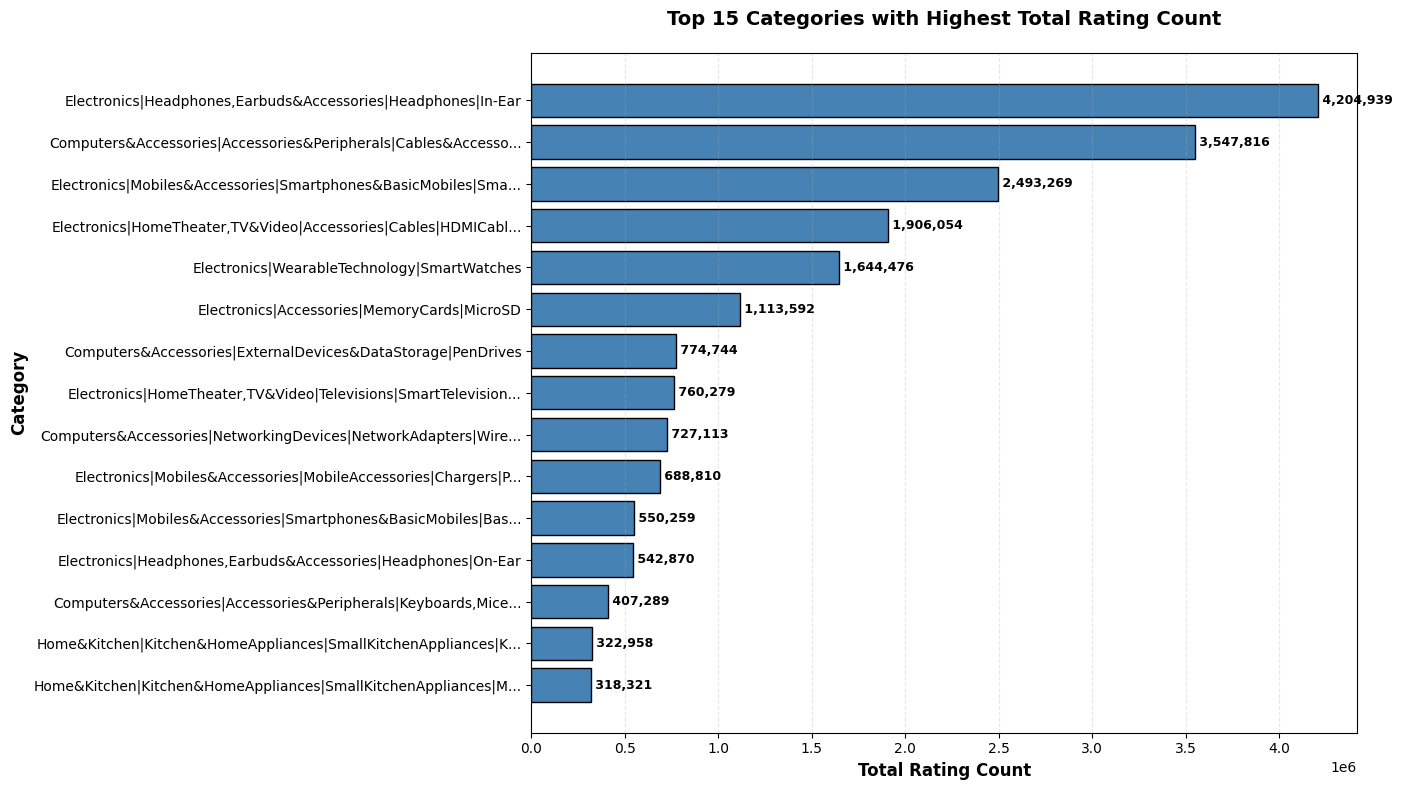

In [176]:
# Visualization 1: Top 15 Categories by Total Rating Count
fig, ax = plt.subplots(figsize=(14, 8))

top_15 = category_stats_sorted.head(15)
bars = ax.barh(range(len(top_15)), top_15['Total_Rating_Count'], color='steelblue', edgecolor='black')

# Add value labels on bars
for i, (idx, row) in enumerate(top_15.iterrows()):
    ax.text(row['Total_Rating_Count'], i, f" {row['Total_Rating_Count']:,.0f}", 
            va='center', fontsize=9, fontweight='bold')

# Shorten category names for display
categories_short = [cat[:60] + '...' if len(cat) > 60 else cat for cat in top_15['Category']]
ax.set_yticks(range(len(top_15)))
ax.set_yticklabels(categories_short, fontsize=10)
ax.set_xlabel('Total Rating Count', fontsize=12, fontweight='bold')
ax.set_ylabel('Category', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Categories with Highest Total Rating Count', fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.invert_yaxis()

plt.tight_layout()
plt.show()


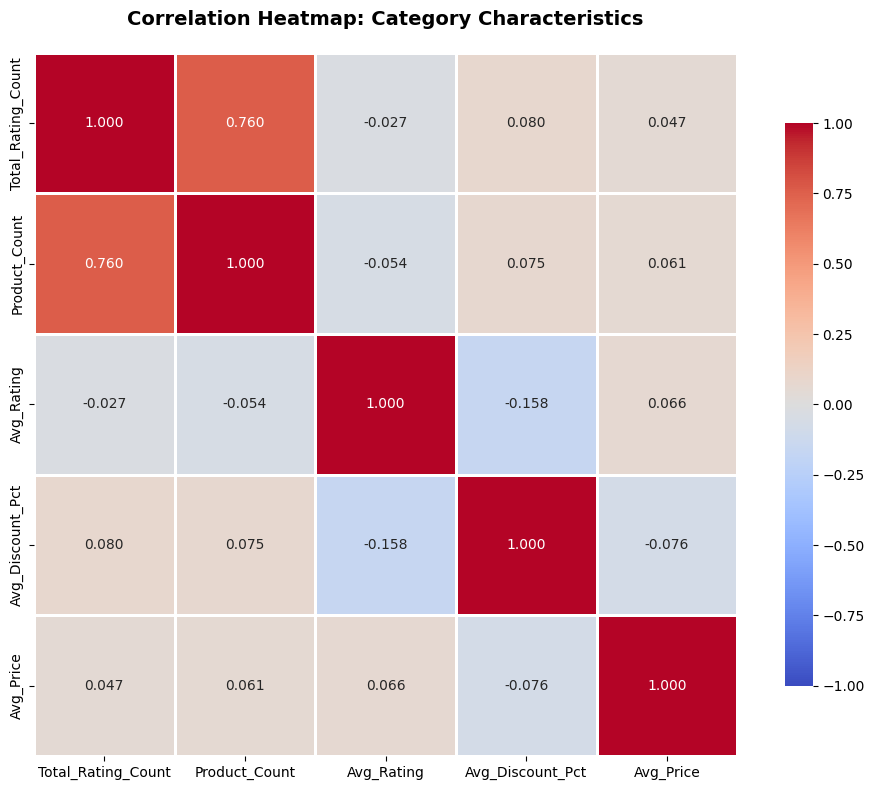

In [177]:
# Visualization 2: Correlation Heatmap
fig, ax = plt.subplots(figsize=(10, 8))

# Create heatmap
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, ax=ax)

ax.set_title('Correlation Heatmap: Category Characteristics', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


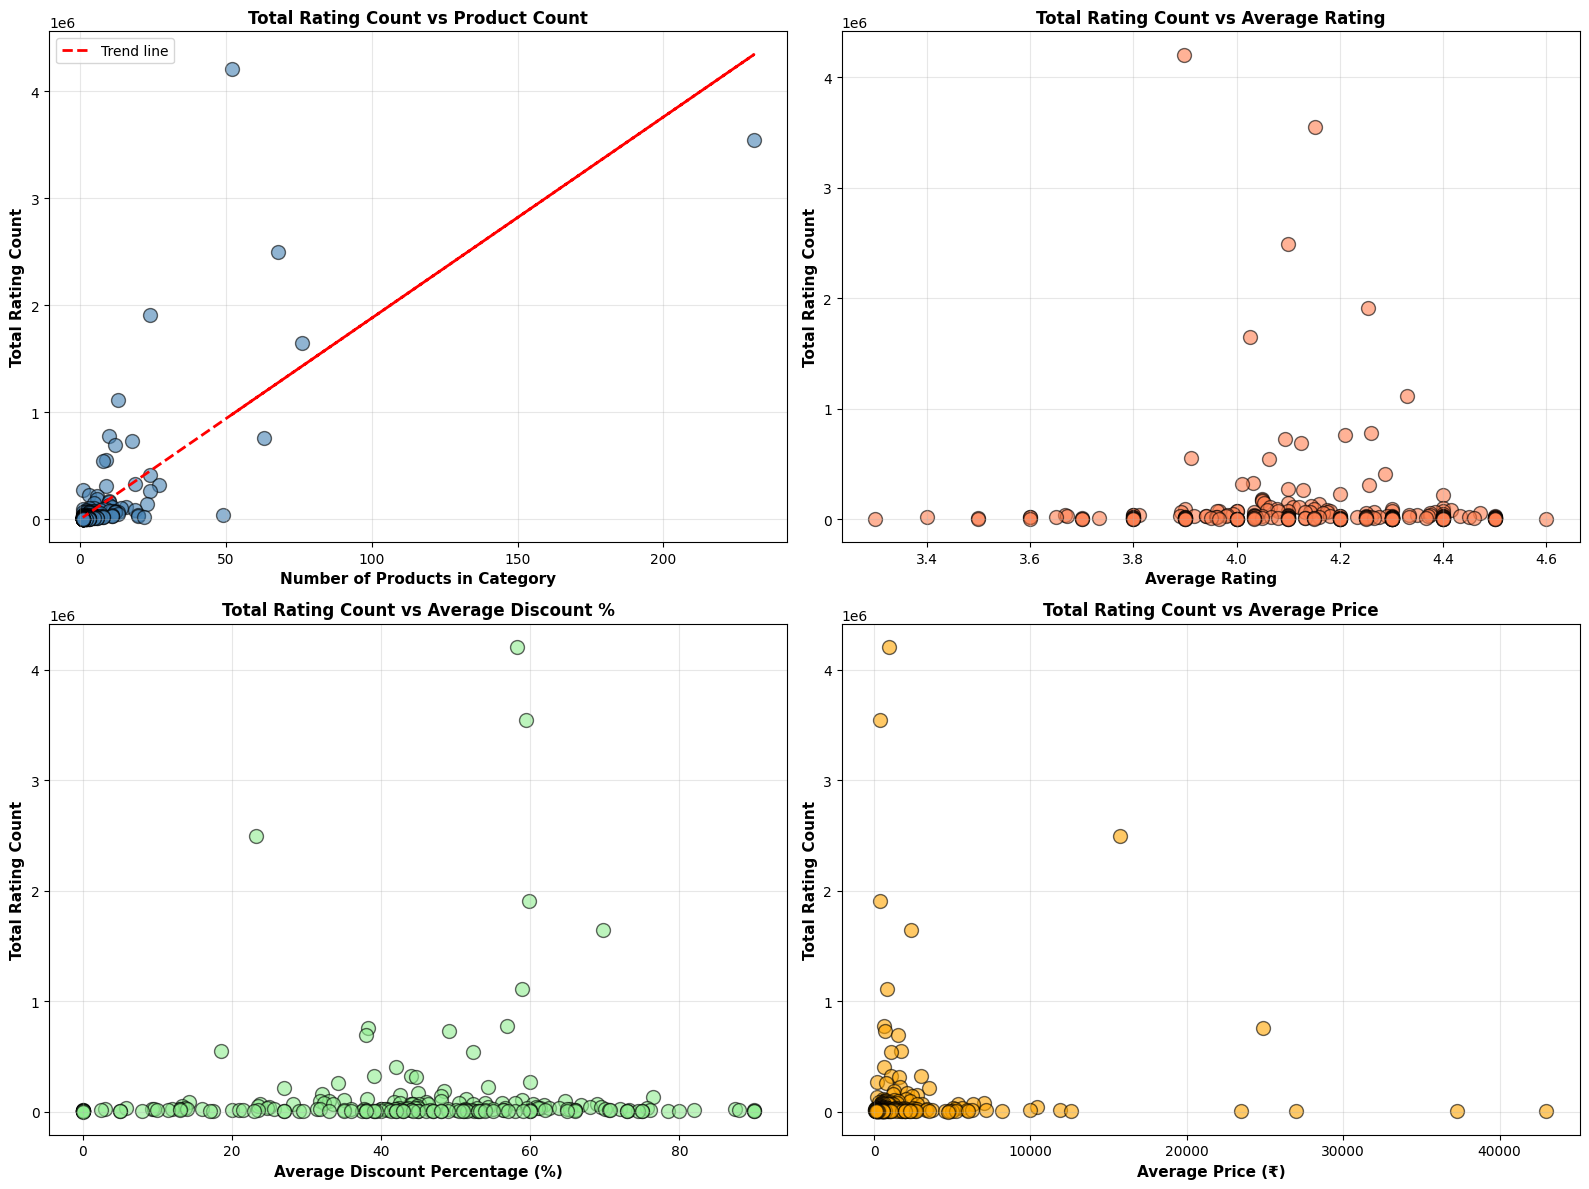

In [178]:
# Visualization 3: Scatter Plots - Rating Count vs Other Variables
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Total Rating Count vs Product Count
axes[0, 0].scatter(category_stats_sorted['Product_Count'], 
                   category_stats_sorted['Total_Rating_Count'],
                   alpha=0.6, s=100, c='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Number of Products in Category', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Total Rating Count', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Total Rating Count vs Product Count', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(category_stats_sorted['Product_Count'], category_stats_sorted['Total_Rating_Count'], 1)
p = np.poly1d(z)
axes[0, 0].plot(category_stats_sorted['Product_Count'], 
                p(category_stats_sorted['Product_Count']), 
                "r--", linewidth=2, label='Trend line')
axes[0, 0].legend()

# Plot 2: Total Rating Count vs Average Rating
axes[0, 1].scatter(category_stats_sorted['Avg_Rating'], 
                   category_stats_sorted['Total_Rating_Count'],
                   alpha=0.6, s=100, c='coral', edgecolor='black')
axes[0, 1].set_xlabel('Average Rating', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Total Rating Count', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Total Rating Count vs Average Rating', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Total Rating Count vs Average Discount
axes[1, 0].scatter(category_stats_sorted['Avg_Discount_Pct'], 
                   category_stats_sorted['Total_Rating_Count'],
                   alpha=0.6, s=100, c='lightgreen', edgecolor='black')
axes[1, 0].set_xlabel('Average Discount Percentage (%)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Total Rating Count', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Total Rating Count vs Average Discount %', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Total Rating Count vs Average Price
axes[1, 1].scatter(category_stats_sorted['Avg_Price'], 
                   category_stats_sorted['Total_Rating_Count'],
                   alpha=0.6, s=100, c='orange', edgecolor='black')
axes[1, 1].set_xlabel('Average Price (₹)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Total Rating Count', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Total Rating Count vs Average Price', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### **5. Statistical Conclusions and Key Findings**

In [179]:
# Final Statistical Summary
print("FINAL STATISTICAL SUMMARY: TOP CATEGORIES WITH HIGHEST RATING COUNT")

print("\nQUESTION ANSWERED: Which product categories have the highest rating counts?")

print("\nTOP 3 CATEGORIES:")
for i, (idx, row) in enumerate(category_stats_sorted.head(3).iterrows(), 1):
    print(f"\n{i}. {row['Category']}")
    print(f"   • Total Rating Count: {row['Total_Rating_Count']:,.0f}")
    print(f"   • Number of Products: {row['Product_Count']:.0f}")
    print(f"   • Average Rating: {row['Avg_Rating']:.2f}/5.0")

print("\nSTATISTICAL MEASURES:")
print(f"   • Maximum rating count: {category_stats_sorted['Total_Rating_Count'].max():,.0f}")
print(f"   • Minimum rating count: {category_stats_sorted['Total_Rating_Count'].min():,.0f}")
print(f"   • Mean rating count: {category_stats_sorted['Total_Rating_Count'].mean():,.2f}")
print(f"   • Median rating count: {category_stats_sorted['Total_Rating_Count'].median():,.2f}")
print(f"   • Standard deviation: {category_stats_sorted['Total_Rating_Count'].std():,.2f}")
print(f"   • Range: {category_stats_sorted['Total_Rating_Count'].max() - category_stats_sorted['Total_Rating_Count'].min():,.0f}")

print("\nKEY INSIGHTS:")

# Insight 1: Distribution skewness
skewness = category_stats_sorted['Total_Rating_Count'].skew()
print(f"\n1. Distribution Analysis:")
print(f"   • Skewness: {skewness:.2f}")
if skewness > 1:
    print(f"   • The distribution is highly right-skewed, indicating most categories have low rating counts")
    print(f"   • A few categories dominate with very high rating counts")
elif skewness > 0:
    print(f"   • The distribution is moderately right-skewed")

# Insight 2: Concentration
top_5_pct = (category_stats_sorted.head(5)['Total_Rating_Count'].sum() / 
             category_stats_sorted['Total_Rating_Count'].sum() * 100)
print(f"\n2. Market Concentration:")
print(f"   • Top 5 categories account for {top_5_pct:.1f}% of all rating counts")
print(f"   • This shows {'high' if top_5_pct > 50 else 'moderate'} concentration in top categories")

# Insight 3: Strongest correlation
strongest_corr = correlation_matrix['Total_Rating_Count'].drop('Total_Rating_Count').abs().idxmax()
strongest_value = correlation_matrix.loc['Total_Rating_Count', strongest_corr]
print(f"\n3. Correlation Insights:")
print(f"   • Strongest predictor of total rating count: {strongest_corr}")
print(f"   • Correlation coefficient: {strongest_value:.4f}")
if strongest_corr == 'Product_Count':
    print(f"   • Categories with more products tend to have higher total rating counts")

print("\nANALYSIS COMPLETE")


FINAL STATISTICAL SUMMARY: TOP CATEGORIES WITH HIGHEST RATING COUNT

QUESTION ANSWERED: Which product categories have the highest rating counts?

TOP 3 CATEGORIES:

1. Electronics|Headphones,Earbuds&Accessories|Headphones|In-Ear
   • Total Rating Count: 4,204,939
   • Number of Products: 52
   • Average Rating: 3.90/5.0

2. Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables
   • Total Rating Count: 3,547,816
   • Number of Products: 231
   • Average Rating: 4.15/5.0

3. Electronics|Mobiles&Accessories|Smartphones&BasicMobiles|Smartphones
   • Total Rating Count: 2,493,269
   • Number of Products: 68
   • Average Rating: 4.10/5.0

STATISTICAL MEASURES:
   • Maximum rating count: 4,204,939
   • Minimum rating count: 224
   • Mean rating count: 126,854.87
   • Median rating count: 18,872.00
   • Standard deviation: 460,575.06
   • Range: 4,204,715

KEY INSIGHTS:

1. Distribution Analysis:
   • Skewness: 6.50
   • The distribution is highly right-skewed, indi